In [2]:
# Setup and Imports
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import umap

# Set professional plotting style
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries loaded successfully.")

d:\Dev\DataFlix\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully.


In [11]:
# Load Evaluation Data
REPORT_PATH = "../results/evaluation_report.json"

with open(REPORT_PATH, "r") as f:
    eval_data = json.load(f)

# Flatten the nested JSON into a Pandas DataFrame for Seaborn
rows = []
for model, segments in eval_data.items():
    for segment, metrics in segments.items():
        rows.append({
            "Model": model,
            "Segment": segment.capitalize(),
            "NDCG@10": metrics.get("ndcg@10", 0),
            "Recall@10": metrics.get("recall@10", 0)
        })

df_metrics = pd.DataFrame(rows)
# Filter out ALS if it's 0.000 to keep the chart clean, or keep it to show the baseline
df_metrics = df_metrics[df_metrics["Model"] != "SASRec"] 

df_metrics.head()

,Model,Segment,NDCG@10,Recall@10
0,TwoTower,Overall,0.030254,0.037635
1,TwoTower,Warm,0.029644,0.035204
2,TwoTower,Cold,0.036453,0.062351
3,ALS,Overall,0.000113,0.000071
4,ALS,Warm,0.000123,0.000076


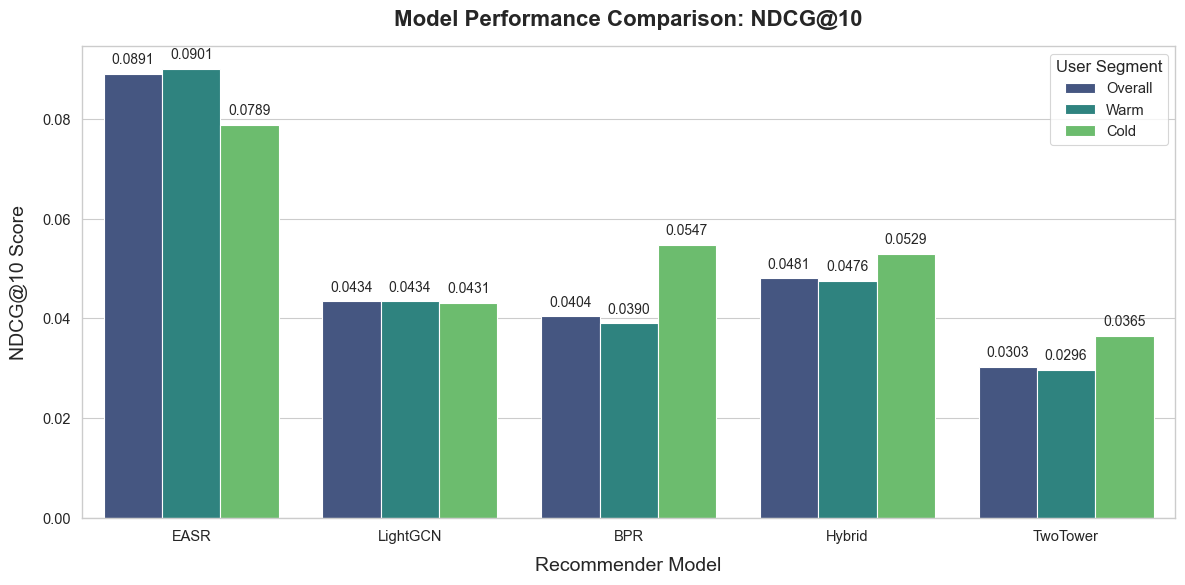

In [12]:
# Bar Chart: NDCG@10 Comparison
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_metrics, 
    x="Model", 
    y="NDCG@10", 
    hue="Segment", 
    palette="viridis",
    order=["EASR", "LightGCN", "BPR", "Hybrid", "TwoTower"] # Adjust based on your final models
)

plt.title("Model Performance Comparison: NDCG@10", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Recommender Model", fontsize=14, labelpad=10)
plt.ylabel("NDCG@10 Score", fontsize=14, labelpad=10)
plt.legend(title="User Segment", title_fontsize="12", loc="upper right")

# Add value labels on top of the bars
for p in ax.patches:
    if p.get_height() > 0.001:  # Only label visible bars
        ax.annotate(f"{p.get_height():.4f}", 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig("../results/ndcg_comparison.png", dpi=300)
plt.show()

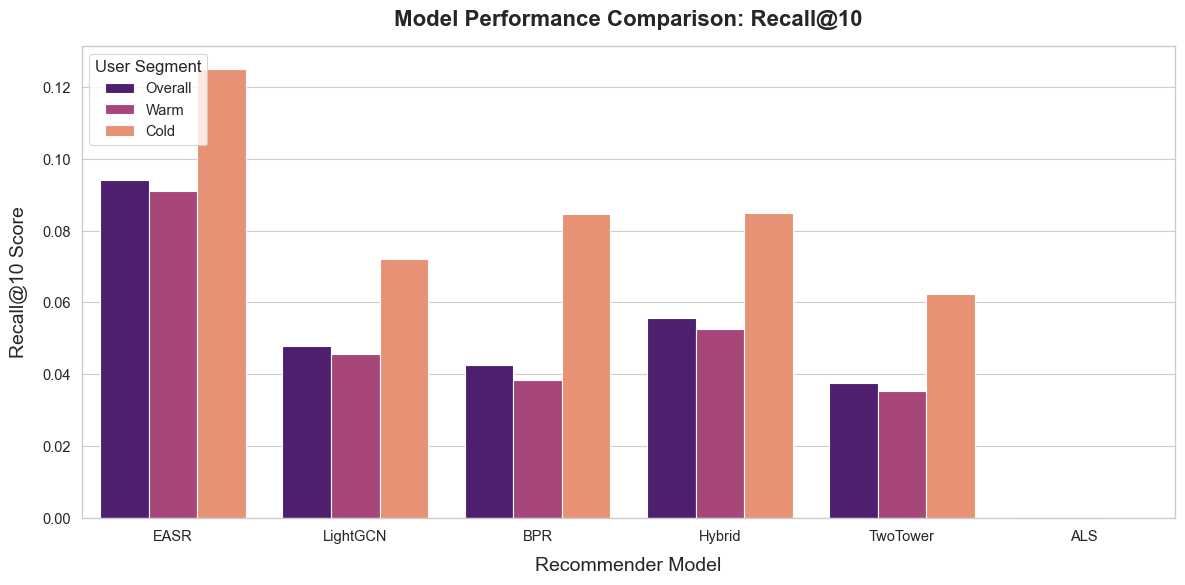

In [13]:
# Bar Chart: Recall@10 Comparison
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df_metrics, 
    x="Model", 
    y="Recall@10", 
    hue="Segment", 
    palette="magma",
    order=["EASR","LightGCN", "BPR", "Hybrid", "TwoTower", "ALS"]
)

plt.title("Model Performance Comparison: Recall@10", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Recommender Model", fontsize=14, labelpad=10)
plt.ylabel("Recall@10 Score", fontsize=14, labelpad=10)
plt.legend(title="User Segment", title_fontsize="12", loc="upper left")

plt.tight_layout()
plt.savefig("../results/recall_comparison.png", dpi=300)
plt.show()

Loading Two-Tower Checkpoint...
Extracted Item Embeddings Shape: (256, 256)
Running UMAP dimensionality reduction (this may take a minute)...


d:\Dev\DataFlix\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


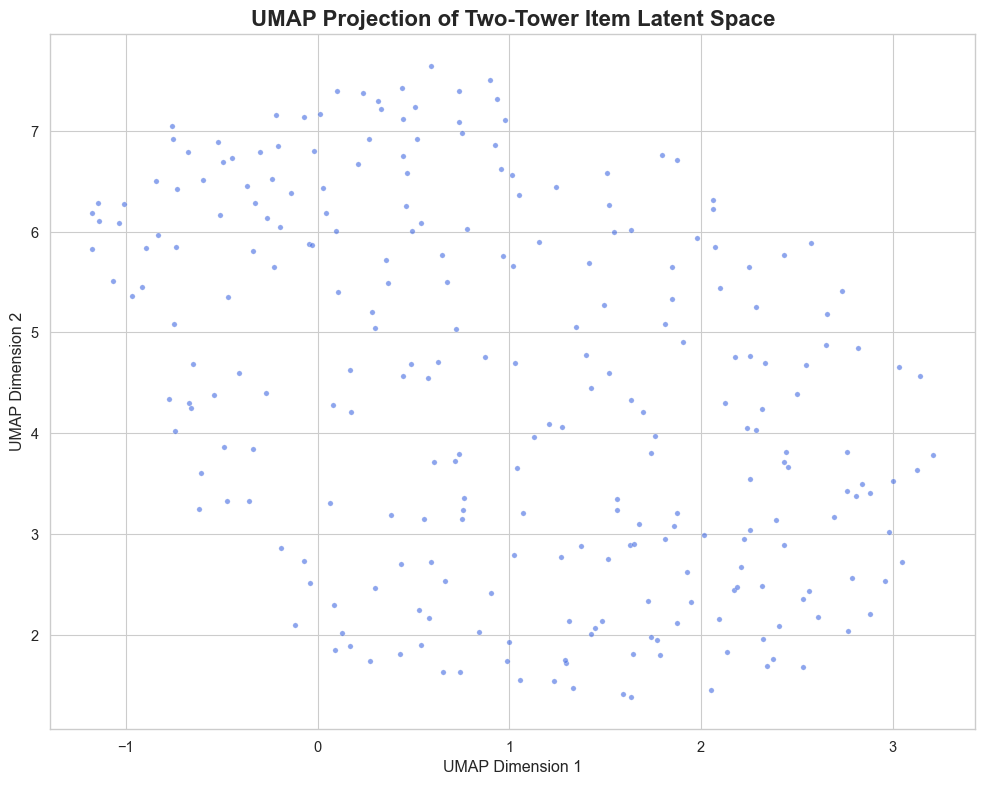

In [6]:
# Semantic Space Visualization via UMAP
TWOTOWER_CKPT = "../results/twotower_best.pt"

print("Loading Two-Tower Checkpoint...")
checkpoint = torch.load(TWOTOWER_CKPT, map_location="cpu")

# Extract the final layer weights from the Item Tower
# Depending on your exact architecture, this might be named differently in the state_dict
# We look for the final linear projection layer in the item_tower
item_weights = None
for key, tensor in checkpoint["model_state"].items():
    if "item_tower" in key and "weight" in key:
        item_weights = tensor.detach().numpy()

if item_weights is not None:
    print(f"Extracted Item Embeddings Shape: {item_weights.shape}")
    
    # We transpose because PyTorch linear layers store weights as (out_features, in_features)
    if item_weights.shape[0] == checkpoint["embed_dim"]:
        embeddings_to_plot = item_weights.T 
    else:
        embeddings_to_plot = item_weights
        
    print("Running UMAP dimensionality reduction (this may take a minute)...")
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
    embedding_2d = reducer.fit_transform(embeddings_to_plot)
    
    plt.figure(figsize=(10, 8))
    # We plot the items as a scatter plot. 
    # In a real presentation, you would color these dots by Movie Genre!
    sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], s=15, alpha=0.6, color="royalblue")
    
    plt.title("UMAP Projection of Two-Tower Item Latent Space", fontsize=16, fontweight="bold")
    plt.xlabel("UMAP Dimension 1")
    plt.ylabel("UMAP Dimension 2")
    
    plt.tight_layout()
    plt.savefig("../results/umap_projection.png", dpi=300)
    plt.show()
else:
    print("Could not locate item tower weights in checkpoint.")